In [1]:
%matplotlib inline
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

import torch
import torch.nn as nn
import gymnasium as gym
from minatar.gym import register_envs
from plotting import plot_compare_smoothed_rewards
from collections import deque

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

## Q3a: Visualization of MinAtar Breakout-v1

In [3]:
# Visualization functions
def visualize_state_per_channel(state):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, ax in enumerate(axes):
        ax.set_title(f'Channel {i}')
        ax.imshow(state[:, :, i], cmap='gray')
    plt.tight_layout()
    plt.show()

def _draw_state(state, ax, title=None):
    """Draw a combined state representation onto the given Axes."""
    n_channels = state.shape[-1]
    cmap_list = [(0, 0, 0)] + sns.color_palette("cubehelix", n_channels)
    cmap = colors.ListedColormap(cmap_list)
    norm = colors.BoundaryNorm(range(n_channels + 2), n_channels + 1)
    numerical_state = np.amax(state * np.arange(1, n_channels + 1), axis=2) + 0.5
    ax.imshow(numerical_state, cmap=cmap, norm=norm, interpolation='none')
    ax.set_title(title or '')
    ax.axis('off')

def visualize_state(state, title=None):
    """Display a single state as a standalone figure."""
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    _draw_state(state, ax, title)
    plt.tight_layout()
    plt.show()

def visualize_states_grid(states, titles=None, ncols=None):
    """Display multiple states in a single figure, laid out row by row."""
    n = len(states)
    if n == 0:
        return
    if titles is None:
        titles = [None] * n
    if ncols is None:
        ncols = n
    nrows = -(-n // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for ax, state, title in zip(axes_flat, states, titles):
        _draw_state(state, ax, title)
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.tight_layout()
    plt.show()

In [4]:
if 'MinAtar/Breakout-v1' not in gym.registry:
    register_envs()

env = gym.make("MinAtar/Breakout-v1")
env.reset(seed=RANDOM_SEED)
env.action_space.seed(RANDOM_SEED)
env.observation_space.seed(RANDOM_SEED)

42

Step 1: Action=0, Reward=0, Done=False
Step 2: Action=2, Reward=0, Done=False
Step 3: Action=1, Reward=0, Done=False
Step 4: Action=1, Reward=0, Done=False
Step 5: Action=1, Reward=0, Done=False


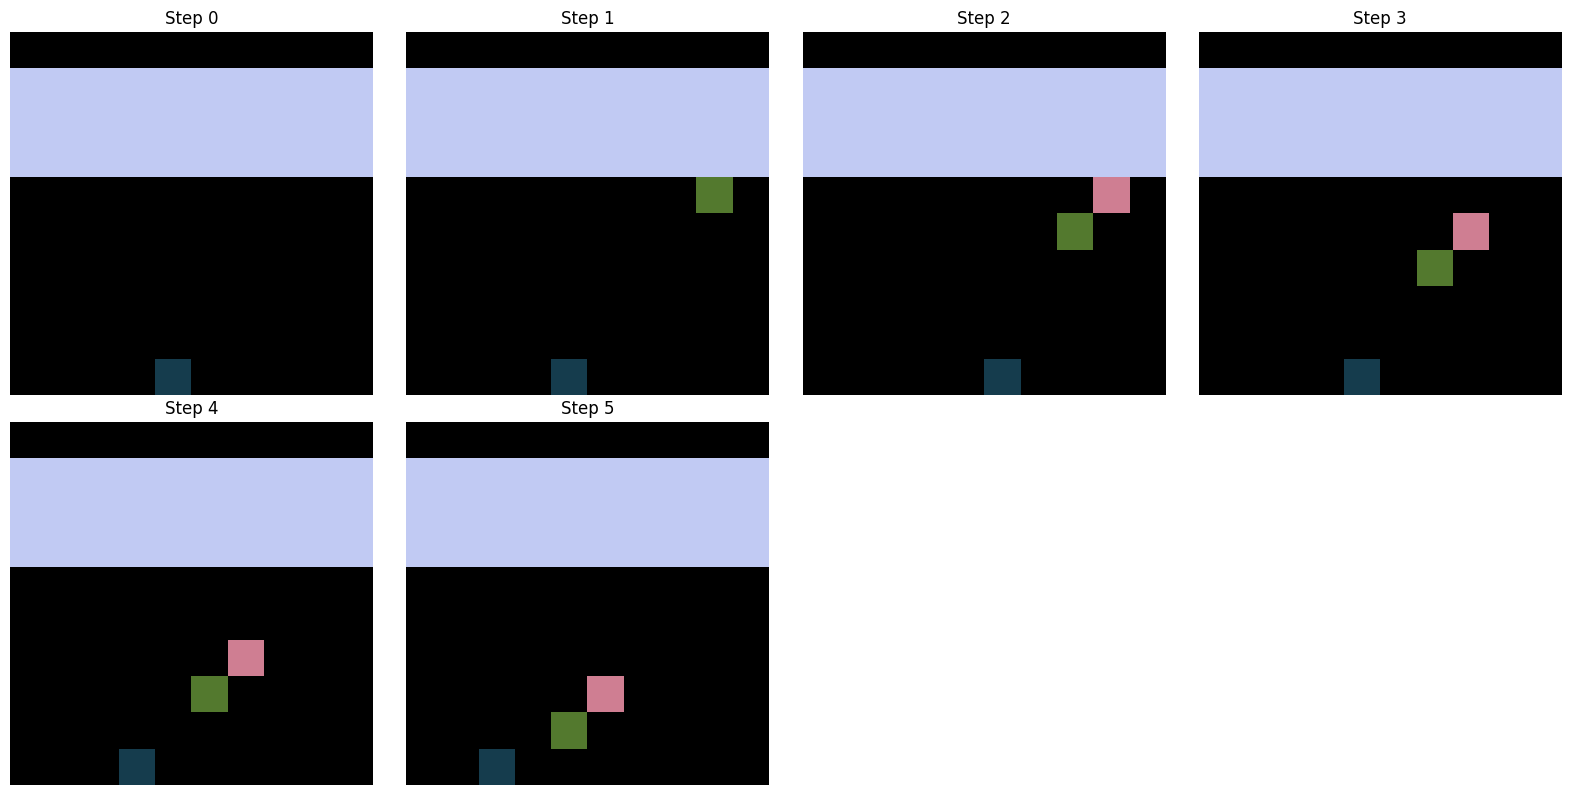

In [5]:
# Take random actions and visualize resulting states
step_states, step_titles = [], []
state, info = env.reset()
step_states.append(state)
step_titles.append("Step 0")

for i in range(5):
    action = env.action_space.sample()
    next_state, reward, done, truncated, info = env.step(action)
    print(f"Step {i+1}: Action={action}, Reward={reward}, Done={done}")
    step_states.append(next_state)
    step_titles.append(f"Step {i+1}")

visualize_states_grid(step_states, titles=step_titles, ncols=4)

In [6]:
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

Observation Space: Box(False, True, (10, 10, 4), bool)
Action Space: Discrete(3)


**(a) Description**
- Dark blue = Paddle
- Green = Current position of the ball
- Pink = Trailing position of the ball
- Purple = Brick

The action space has three actions: stay (0), left (1), right (2). These control the paddle. The ball spawns from the left or right side and moves diagonally. If the paddle misses the ball, the episode ends. You get one point for each brick hit with the ball.

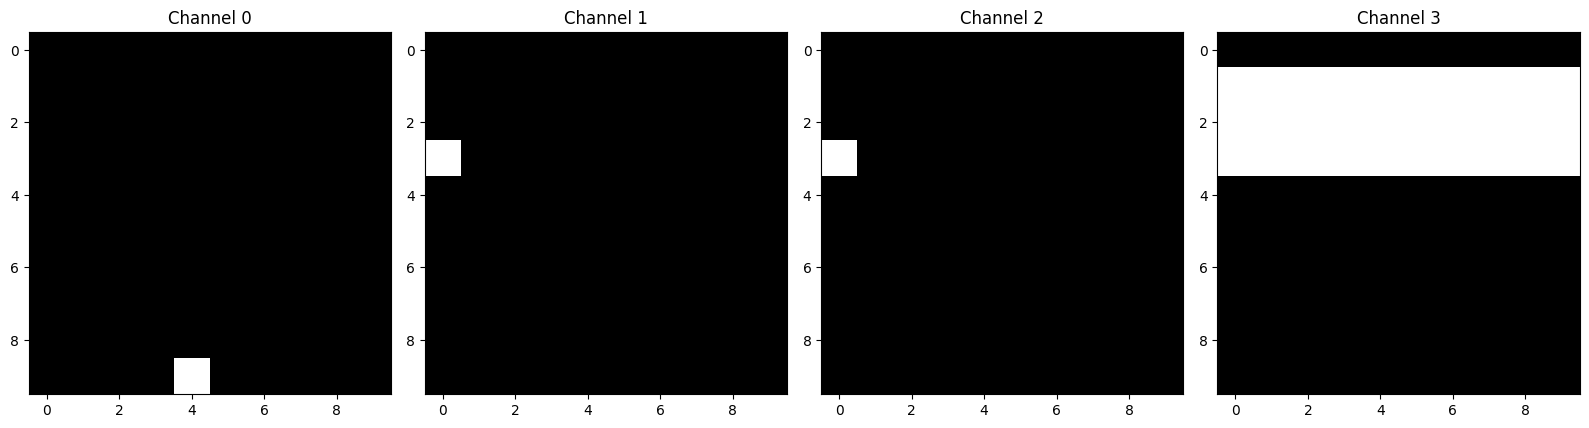

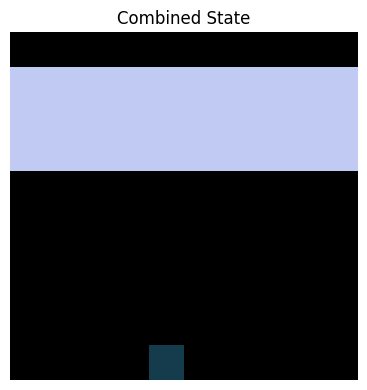

In [7]:
state, info = env.reset()
visualize_state_per_channel(state)
visualize_states_grid([state], titles=["Combined State"])

**(a1) Non-Markovian observation process**

At the beginning of every episode, the ball spawns behind the bricks and appears either from the left or from the right of the screen.

During game play, the state contains the ball's current position and its position at the previous time step. This is Markovian in the sense that from the information only contained in the state, an agent could deduce where the ball is going next. However, after each reset, the current position of the ball overlaps with the previous position of the ball, and the initial step is slightly non-Markovian, in the sense the agent does not have sufficient information from the state to know where the ball is going next. This can be seen when we visualize each channel in the (10,10,4) state. 

## Q3b: Control with Experience Replay

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)
        self.relu = nn.ReLU()

        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.uniform_(layer.weight, a=-0.001, b=0.001)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

### (i) Sequential Updates (no replay buffer)

In [9]:
GAMMA = 0.99
WARMUP_STEPS = 1000
BATCH_SIZE = 64

In [10]:
def run_sequential_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3],
    num_episodes=3000,
    num_runs=5,
    eps=0.05,
    warmup_steps=1000,
    device="cpu"
):
    if device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
    print(f"Using device: {device}")

    loss_fn = nn.MSELoss()
    return_results = {}
    loss_results = {}
    models = {}

    for lr in learning_rates:
        print(f"Sequential DQN | lr={lr}")
        lr_returns = []
        lr_losses = []
        lr_models = []

        for run in range(num_runs):
            # Ensure different seed for each run
            env.reset(seed= RANDOM_SEED + run)

            Q = MLP(input_dim=400, output_dim=3).to(device)
            optimizer = torch.optim.Adam(Q.parameters(), lr=lr)

            target_Q = MLP(input_dim=400, output_dim=3).to(device)
            target_Q.load_state_dict(Q.state_dict())
            reset_target_steps = 1000
            step_count = 0

            run_returns = []
            run_losses = []

            for episode in range(num_episodes):
                state, info = env.reset()
                done = False
                truncated = False
                episode_return = 0
                episode_loss_sum = 0
                episode_steps = 0

                while not (done or truncated):
                    # Flatten the current state and convert to PyTorch tensor
                    state_tensor = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0).to(device) # [1, 400]

                    # Select action according to epsilon-greedy
                    if step_count < warmup_steps:
                         action = env.action_space.sample()
                    elif random.random() < eps:
                        action = env.action_space.sample()
                    else:
                        with torch.no_grad():
                            action = Q(state_tensor).argmax().item()

                    next_state, reward, done, truncated, info = env.step(action)
                    episode_return += GAMMA ** episode_steps * reward

                    step_count += 1
                    episode_steps += 1

                    # Train after warmup
                    loss_val = 0
                    if step_count > warmup_steps:
                        prediction = Q(state_tensor)[0, action]

                        # Compute Target
                        with torch.no_grad():
                            next_state_tensor = torch.tensor(next_state.flatten(), dtype=torch.float32).unsqueeze(0).to(device)
                            target = reward + GAMMA * target_Q(next_state_tensor).max() * (1 - int(done))

                        # Compute loss
                        loss = loss_fn(prediction, target)
                        loss_val = loss.item()

                        # Backpropagate gradients and update weights in Q-network
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                        # Update target network periodically
                        if step_count % reset_target_steps == 0:
                            target_Q.load_state_dict(Q.state_dict())

                    # Track metrics and transition to next state
                    episode_loss_sum += loss_val
                    state = next_state

                run_returns.append(episode_return)
                run_losses.append(episode_loss_sum / episode_steps)

            lr_returns.append(run_returns)
            lr_losses.append(run_losses)
            lr_models.append({k: v.cpu() for k, v in Q.state_dict().items()})

        return_results[lr] = lr_returns
        loss_results[lr] = lr_losses
        models[lr] = lr_models

    return return_results, loss_results, models

### (ii) Experience Replay with Uniform Sampling

In [11]:
class ReplayBuffer:
    def __init__(self, capacity=50000):
        # deque automatically discards the oldest items when maxlen is reached
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

In [12]:
def run_replay_uniform_sampling_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3],
    num_episodes=3000,
    num_runs=5,
    eps=0.05,
    warmup_steps=1000,
    device="cpu"
):
    if device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
    print(f"Using device: {device}")

    loss_fn = nn.MSELoss()
    return_results = {}
    loss_results = {}
    models = {}

    for lr in learning_rates:
        print(f"Uniform Replay DQN | lr={lr}")
        lr_returns = []
        lr_losses = []
        lr_models = []

        for run in range(num_runs):
            # Ensure different seed for each run
            env.reset(seed = RANDOM_SEED + run)

            # Initialize replay buffer with capacity of 50000 transitions
            replay_buffer = ReplayBuffer(capacity=50000)

            # Initialize Q-network and Adam optimizer
            Q = MLP(input_dim=400, output_dim=3).to(device)
            optimizer = torch.optim.Adam(Q.parameters(), lr=lr)

            # Initialize the target network and copy weights from Q-network
            target_Q = MLP(input_dim=400, output_dim=3).to(device)
            target_Q.load_state_dict(Q.state_dict())
            reset_target_steps = 1000  # Update target network every 1000 steps
            step_count = 0
            
            run_returns = [] 
            run_losses = []

            # Start training the agent
            for episode in range(num_episodes):
                state, info = env.reset()
                done = False
                truncated = False
                episode_return = 0
                episode_loss_sum = 0
                episode_steps = 0

                while not (done or truncated):
                    # Flatten the current state and convert to PyTorch tensor
                    state_tensor = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0).to(device) # [1, 400]

                    # Select action according to epsilon-greedy
                    if step_count < warmup_steps:
                         action = env.action_space.sample()
                    elif random.random() < eps:
                        action = env.action_space.sample()
                    else:
                        with torch.no_grad():
                            action = Q(state_tensor).argmax().item()

                    next_state, reward, done, truncated, info = env.step(action)

                    # Add discounted reward for this step to episode return
                    episode_return += GAMMA ** episode_steps * reward

                    # Store transition in replay buffer
                    replay_buffer.push(state.flatten(), action, reward, next_state.flatten(), done)
                    
                    # Only train after warmup steps
                    loss_val = 0
                    if step_count > warmup_steps and len(replay_buffer) >= BATCH_SIZE:
                        # Sample a batch from the replay buffer
                        states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch = replay_buffer.sample(BATCH_SIZE)
                        
                        states_tensor = torch.tensor(states_batch, dtype=torch.float32).to(device)
                        actions_tensor = torch.tensor(actions_batch, dtype=torch.int64).to(device)
                        rewards_tensor = torch.tensor(rewards_batch, dtype=torch.float32).to(device)
                        next_states_tensor = torch.tensor(next_states_batch, dtype=torch.float32).to(device)
                        dones_tensor = torch.tensor(dones_batch, dtype=torch.float32).to(device)

                        predictions = Q(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

                        # Compute Target
                        with torch.no_grad():
                            targets = rewards_tensor + GAMMA * target_Q(next_states_tensor).max(1)[0] * (1 - dones_tensor)

                        # Compute loss
                        loss = loss_fn(predictions, targets)
                        loss_val = loss.item()

                        # Backpropagate gradients and update weights in Q-network
                        optimizer.zero_grad() 
                        loss.backward()
                        optimizer.step()

                        # Update target network periodically
                        if step_count % reset_target_steps == 0:
                            target_Q.load_state_dict(Q.state_dict())

                    # Track metrics and transition to next state
                    episode_loss_sum += loss_val
                    step_count += 1
                    episode_steps += 1
                    state = next_state
                
                run_returns.append(episode_return)
                run_losses.append(episode_loss_sum / episode_steps)

            lr_returns.append(run_returns)
            lr_losses.append(run_losses)
            lr_models.append({k: v.cpu() for k, v in Q.state_dict().items()})

        return_results[lr] = lr_returns
        loss_results[lr] = lr_losses
        models[lr] = lr_models

    return return_results, loss_results, models

### (iii) Experience Replay with Prioritized Sampling

In [13]:
ALPHA = 0.6
BETA = 0.4

In [14]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity=50000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = []
        self.write_idx = 0

    def push(self, state, action, reward, next_state, done):
        # New transitions get the maximum priority currently in the buffer to ensure they are sampled at least once.
        max_priority = max(self.priorities) if self.priorities else 1.0
        
        # If buffer not full, append the transition and its priority.
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
            self.priorities.append(max_priority)
        # If buffer full, overwrite at self.write_id.
        else:
            self.buffer[self.write_idx] = (state, action, reward, next_state, done)
            self.priorities[self.write_idx] = max_priority
            self.write_idx = (self.write_idx + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == 0:
            return None

        # P(j) = p_j^alpha / sum(p_i^alpha)
        priorities = np.array(self.priorities, dtype=np.float32)
        scaled_priorities = priorities ** self.alpha
        P = scaled_priorities / np.sum(scaled_priorities)
        
        # Sample indices based on P(j) distribution
        indices = np.random.choice(len(self.buffer), batch_size, p=P)

        # Retrieve the transitions for these indices.
        samples = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*samples)

        # IS weights: w_j = (N * P(j))^{-beta} / max(w)
        weights = (len(self.buffer) * P[indices]) ** (-beta)
        weights = weights / np.max(weights)

        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones), indices, weights)

    def update_priorities(self, batch_indices, batch_priorities):
        for i, priority in zip(batch_indices, batch_priorities):
            self.priorities[i] = priority

    def __len__(self):
        return len(self.buffer)

In [ ]:
def run_prioritized_replay_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3],
    num_episodes=3000,
    num_runs=5,
    eps=0.05,
    warmup_steps=1000,
    buffer_capacity=50000,
    alpha=0.6,
    beta_start=0.4,
    stability_epsilon=1e-6,
    device="cpu"
):
    if device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
    print(f"Using device: {device}")

    loss_fn = nn.MSELoss(reduction='none')
    return_results = {}
    loss_results = {}
    models = {}

    for lr in learning_rates:
        print(f"Prioritized Replay DQN | lr={lr}")
        lr_returns = []
        lr_losses = []
        lr_models = []

        for run in range(num_runs):
            env.reset(seed=RANDOM_SEED + run)
            replay_buffer = PrioritizedReplayBuffer(capacity=buffer_capacity, alpha=alpha)

            Q = MLP(input_dim=400, output_dim=3).to(device)
            optimizer = torch.optim.Adam(Q.parameters(), lr=lr)
            target_Q = MLP(input_dim=400, output_dim=3).to(device)
            target_Q.load_state_dict(Q.state_dict())

            reset_target_steps = 1000
            step_count = 0
            
            run_returns = [] 
            run_losses = []
            
            # Beta annealing: start at beta_start and linearly increase to 1.0
            beta = beta_start
            beta_increment = (1.0 - beta_start) / num_episodes

            for episode in range(num_episodes):
                state, info = env.reset()
                done = False
                truncated = False
                episode_return = 0
                episode_loss_sum = 0
                episode_steps = 0
                
                # Update beta for this episode
                beta = min(1.0, beta + beta_increment)

                while not (done or truncated):
                    state_tensor = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0).to(device)

                    if step_count < warmup_steps:
                        action = env.action_space.sample()
                    elif random.random() < eps:
                        action = env.action_space.sample()
                    else:
                        with torch.no_grad():
                            action = Q(state_tensor).argmax().item()

                    next_state, reward, done, truncated, info = env.step(action)
                    episode_return += GAMMA ** episode_steps * reward

                    # Store transition in replay buffer
                    replay_buffer.push(state.flatten(), action, reward, next_state.flatten(), done)

                    loss_val = 0
                    if step_count > warmup_steps and len(replay_buffer) >= BATCH_SIZE:
                        # Sample batch with importance weights
                        states, actions, rewards, next_states, dones, indices, weights = replay_buffer.sample(BATCH_SIZE, beta=beta)
                        
                        # Convert to tensors
                        states_tensor = torch.tensor(states, dtype=torch.float32).to(device) # [BATCH_SIZE, 400]
                        actions_tensor = torch.tensor(actions, dtype=torch.int64).to(device)
                        rewards_tensor = torch.tensor(rewards, dtype=torch.float32).to(device)
                        next_states_tensor = torch.tensor(next_states, dtype=torch.float32).to(device)
                        dones_tensor = torch.tensor(dones, dtype=torch.float32).to(device)
                        weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

                        predictions = Q(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

                        # Compute Target
                        with torch.no_grad():
                            target_q_values = target_Q(next_states_tensor)
                            targets = rewards_tensor + GAMMA * target_q_values.max(1)[0] * (1 - dones_tensor)
                        
                        # Compute Loss
                        # Need weighted loss: average of (weights * (prediction - target)^2)
                        elementwise_loss = loss_fn(predictions, targets)
                        loss = (elementwise_loss * weights_tensor).mean()
                        loss_val = loss.item()
                        
                        # 5. Optimize
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                        # Update priorities: |TD error| + epsilon
                        td_errors = torch.abs(predictions - targets).detach().cpu().numpy()
                        replay_buffer.update_priorities(indices, td_errors + stability_epsilon)

                        if step_count % reset_target_steps == 0:
                            target_Q.load_state_dict(Q.state_dict())

                    episode_loss_sum += loss_val
                    step_count += 1
                    episode_steps += 1
                    state = next_state

                run_returns.append(episode_return)
                run_losses.append(episode_loss_sum / episode_steps if episode_steps > 0 else 0)

            lr_returns.append(run_returns)
            lr_losses.append(run_losses)
            lr_models.append({k: v.cpu() for k, v in Q.state_dict().items()})

        return_results[lr] = lr_returns
        loss_results[lr] = lr_losses
        models[lr] = lr_models

    return return_results, loss_results, models

Using device: cpu
Sequential DQN | lr=0.0001
Sequential DQN | lr=0.0005
Sequential DQN | lr=0.001


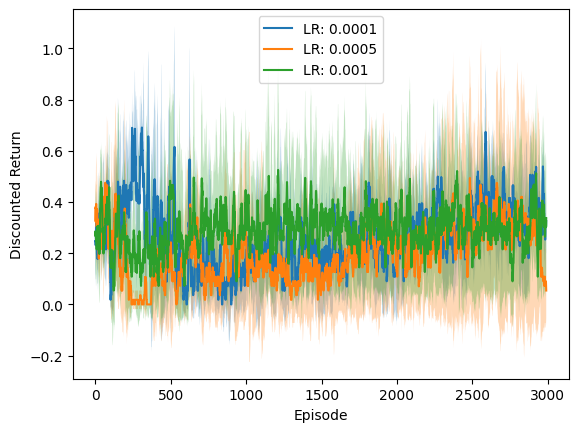

Using device: cuda
Uniform Replay DQN | lr=0.0001
Uniform Replay DQN | lr=0.0005
Uniform Replay DQN | lr=0.001


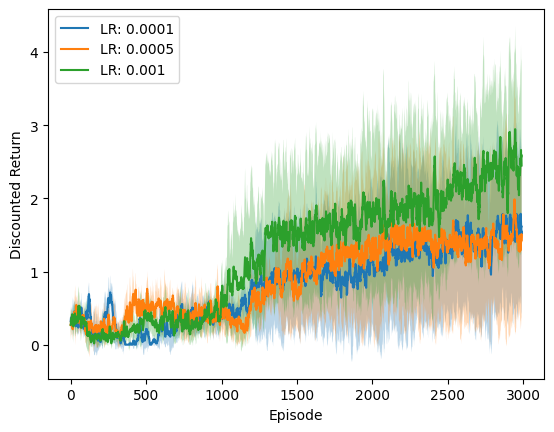

Using device: cuda
Prioritized Replay DQN | lr=0.0001
Prioritized Replay DQN | lr=0.0005
Prioritized Replay DQN | lr=0.001


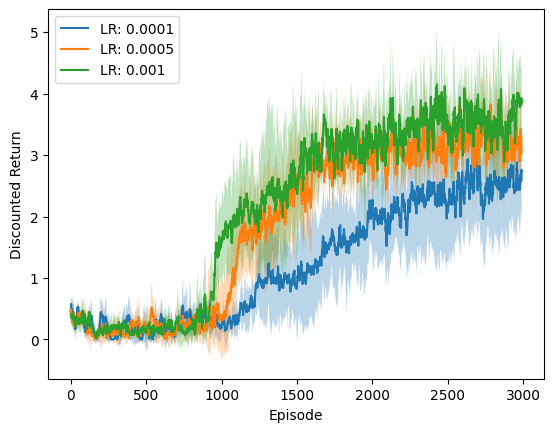

In [16]:
# DQN with sequential updates
returns, losses, seq_models = run_sequential_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3],
    num_episodes=3000,
    num_runs=5,
    warmup_steps=1000,
    device="cpu"
)

all_methods_data = []
all_labels = []
for lr, seeds_data in returns.items():
    all_methods_data.append(seeds_data)
    all_labels.append(f"LR: {lr}")

plot_compare_smoothed_rewards(
    train_rewards_list=all_methods_data,
    labels=all_labels,
    xlabel="Episode",
    ylabel="Discounted Return"
)

# DQN with Experience Replay and Uniform Sampling
returns, losses, replay_models = run_replay_uniform_sampling_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3],
    num_episodes=3000,
    num_runs=5,
    eps=0.05,
    warmup_steps=1000,
    device="cuda"
)

all_methods_data = []
all_labels = []
for lr, seeds_data in returns.items():
    all_methods_data.append(seeds_data)
    all_labels.append(f"LR: {lr}")

plot_compare_smoothed_rewards(
    train_rewards_list=all_methods_data,
    labels=all_labels,
    xlabel="Episode",
    ylabel="Discounted Return"
)

# DQN with Experience Replay and Prioritized Sampling
returns, losses, per_models = run_prioritized_replay_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3],
    num_episodes=3000,
    num_runs=5,
    eps=0.05,
    warmup_steps=1000,
    buffer_capacity=50000,
    alpha=0.6,
    beta_start=0.4,
    stability_epsilon=1e-6,
    device="cuda"
)

all_methods_data = []
all_labels = []
for lr, seeds_data in returns.items():
    all_methods_data.append(seeds_data)
    all_labels.append(f"LR: {lr}")

plot_compare_smoothed_rewards(
    train_rewards_list=all_methods_data,
    labels=all_labels,
    xlabel="Episode",
    ylabel="Discounted Return"
)

**Answer:**
DQN with Experience Replay + Uniform Sampling performs significantly better than DQN with sequential updates. There are a few main plausible reasons. First, a replay buffer allows the agent to use its data more efficiently since one sampled transition can be used in multiple weight updates, whereas each sample is used only once and thrown away in sequential updates. This is especially important in Breakout-v1 because the agent performs poorly in most early episodes which end quickly, but occasionally catches the ball and generates some reward signal. Without a replay buffer, the transitions from this good episode are used to update weights only once. With a buffer, they can be reused multiple times, helping the agent improve faster. Second, sequential samples are strongly correlated (not i.i.d.), but sampling uniformly from a buffer of past transitions breaks this correlation, reducing the variance of updates and improving SGD stability.

Within the Experience Replay variants, we observed that Prioritized Sampling performs better than Uniform Sampling. Our update rule uses one-step TD error, which bootstraps. When the agent bounces the ball off the paddle and hits bricks, the resulting non-zero reward creates high TD-error at those transitions, and credit assignment to the preceding states and actions that led to that outcome takes time to propagate. Prioritized Sampling replays these high-error transitions more frequently, accelerating the propagation of useful learning signal. At the same time, it corrects the resulting sampling bias with importance sampling weights. This could plausibly explain why it outperforms uniform sampling in the same number of training episodes.

## Q4: Deep Policy-based Methods for Control (CartPole-v1)

In [17]:
GAMMA = 0.99

In [18]:
# Initialize CartPole-v1 environment
env = gym.make("CartPole-v1")
env.reset(seed=RANDOM_SEED)
env.action_space.seed(RANDOM_SEED)
env.observation_space.seed(RANDOM_SEED)

# Environment specifications
print(f"CartPole-v1 Environment specifications")
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

CartPole-v1 Environment specifications
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)


### Q4a: REINFORCE and REINFORCE with Baseline

In [19]:
# Run one episode with random actions for 5 steps
state, info = env.reset()
print(f"Initial state: {state}")
print(f"type(state): {type(state)}, shape: {state.shape}")

done = False
truncated = False
i = 0
while not done and not truncated and i < 5:
    i += 1
    action = env.action_space.sample()
    next_state, reward, done, truncated, info = env.step(action)
    print(f"Step: {i}, Action: {action}, Reward: {reward}, Done: {done}, Truncated: {truncated}")

Initial state: [-0.04058227  0.04756223  0.02611397  0.02860643]
type(state): <class 'numpy.ndarray'>, shape: (4,)
Step: 1, Action: 0, Reward: 1.0, Done: False, Truncated: False
Step: 2, Action: 1, Reward: 1.0, Done: False, Truncated: False
Step: 3, Action: 1, Reward: 1.0, Done: False, Truncated: False
Step: 4, Action: 0, Reward: 1.0, Done: False, Truncated: False
Step: 5, Action: 0, Reward: 1.0, Done: False, Truncated: False


In [20]:
class BoltzmanPolicy(nn.Module):
    def __init__(self, input_dim, output_dim, initial_temperature=1.0):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)
        self.relu = nn.ReLU()
        self.temperature = initial_temperature
        self.softmax = nn.Softmax(dim=-1)

        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.uniform_(layer.weight, a=-0.001, b=0.001)
            nn.init.zeros_(layer.bias)

    def decay_temperature(self, decay_rate, T_min=0.5):
        self.temperature = max(T_min, decay_rate * self.temperature)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        logits = self.fc3(x)
        return self.softmax(logits / self.temperature)

In [21]:
def compute_returns(rewards, gamma):
    """Compute discounted returns G_t and discount factors gamma^t for each timestep."""
    returns = []
    gammas = []
    G = 0
    t = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
        gammas.append(gamma ** t)
        t += 1
    returns.reverse()
    return returns, gammas

In [22]:
def run_reinforce(
    lr= 1e-4,
    T_initial= 10,
    T_decay = 0.99,
    T_min = 0.5,
    isDecay = True,
    num_episodes = 1000,
    num_runs = 5,
    device = "cpu"
):
    if device not in ["cpu", "cuda", "mps"]:
        raise ValueError(f"Invalid device '{device}'. Supported devices are 'cpu', 'cuda', and 'mps'.")
    elif device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
        print("cuda not available, falling back to cpu.")
    else:
        print(f"Using device: {device}")

    print(f"Running REINFORCE with learning rate: {lr}, initial temperature: {T_initial}, isDecay: {isDecay}")

    all_returns = [] # Store return results for each run

    for run in range(num_runs):
        # Ensure different seed for each run
        env.reset(seed = RANDOM_SEED + run)

        # Initialize differentiable policy parameterization
        policy = BoltzmanPolicy(input_dim = 4, output_dim = 2, initial_temperature = T_initial).to(device)

        # Initialize Adam optimizer for policy parameters with default hyperparameters
        optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

        # Track discounted return for each episode
        run_returns = []

        # Run training loop for specified number of episodes
        for episode in range(num_episodes):
            state, info = env.reset()

            episode_return = 0.0
            episode_steps = 0
            done = False
            truncated = False

            # Store (state, action, reward) for each step in the episode
            transitions = []

            while not (done or truncated):
                # Sample an action from the policy given the current state
                with torch.no_grad():
                    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)  # [1, 4]
                    action_probs = policy(state_tensor).squeeze(0) # [2]
                    action = torch.multinomial(action_probs, num_samples=1).item()

                # Take the action in the environment
                next_state, reward, done, truncated, info = env.step(action)

                # Store the transition
                transitions.append((state, action, reward))

                # Update episode return and step count
                episode_return += (GAMMA ** episode_steps) * reward
                episode_steps += 1
                state = next_state
            
            # After the episode ends, compute returns and update policy
            states, actions, rewards = zip(*transitions)
            returns, gammas = compute_returns(rewards, GAMMA) # List of returns and gammas for each step

            # Convert to numpy arrays to avoid "Creating a tensor from a list of numpy.ndarrays is extremely slow" warning
            states = np.array(states)
            actions = np.array(actions)
            returns = np.array(returns) 
            gammas = np.array(gammas)
            
            # Convert to tensors
            states_tensor = torch.tensor(states, dtype=torch.float32).to(device) # [total_episode_steps, 4],
            actions_tensor = torch.tensor(actions, dtype=torch.int64).to(device) # [total_episode_steps]
            returns_tensor = torch.tensor(returns, dtype=torch.float32).to(device) # [total_episode_steps]
            gammas_tensor = torch.tensor(gammas, dtype=torch.float32).to(device) # [total_episode_steps]

            # Compute action probabilities for all states in the episode
            action_probs = policy(states_tensor) # [total_episode_steps, 2]
            selected_action_probs = action_probs.gather(1, actions_tensor.unsqueeze(1)).squeeze(1) # [total_episode_steps]
            log_selected_action_probs = torch.log(selected_action_probs + 1e-8) # [total_episode_steps]

            # Compute a sample of the policy gradient deltaJ
            gradientJ = (gammas_tensor * returns_tensor * log_selected_action_probs).sum() # scalar
            loss = -gradientJ

            # Update parameters using the policy gradient estimate
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Decay temperature
            if isDecay:
                policy.decay_temperature(decay_rate=T_decay, T_min=T_min)

            run_returns.append(episode_return)
            
        all_returns.append(run_returns)
        
    return all_returns

In [23]:
def run_reinforce_with_baseline(
    lr_pi=1e-4,
    lr_v=1e-3,
    T_initial=10,
    T_decay=0.99,
    T_min=0.5,
    isDecay=True,
    num_episodes=1000,
    num_runs=5,
    device="cpu"
):
    if device not in ["cpu", "cuda", "mps"]:
        raise ValueError(f"Invalid device '{device}'. Supported devices are 'cpu', 'cuda', and 'mps'.")
    elif device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
        print("cuda not available, falling back to cpu.")
    else:
        print(f"Using device: {device}")

    print(f"Running REINFORCE with Baseline. Policy network LR: {lr_pi}, Value function LR: {lr_v}. Initial temperature: {T_initial}, isDecay: {isDecay}")

    all_returns = [] # Store return results for each run

    for run in range(num_runs):
        # Ensure different seed for each run
        env.reset(seed = RANDOM_SEED + run)

        # Initialize differentiable policy parameterization
        policy = BoltzmanPolicy(input_dim = 4, output_dim = 2, initial_temperature = T_initial).to(device)
        value = MLP(input_dim = 4, output_dim = 1).to(device)

        # Initialize Adam optimizer for policy parameters with default hyperparameters
        optimizer = torch.optim.Adam(policy.parameters(), lr=lr_pi)
        value_optimizer = torch.optim.Adam(value.parameters(), lr=lr_v)
        run_returns = []

        for episode in range(num_episodes):
            state, info = env.reset()

            episode_return = 0.0
            episode_steps = 0
            done = False
            truncated = False

            # Store (state, action, reward) for each step in the episode
            transitions = []

            while not (done or truncated):
                # Sample an action from the policy given the current state
                with torch.no_grad():
                    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)  # [1, 4]
                    action_probs = policy(state_tensor).squeeze(0) # [2]
                    action = torch.multinomial(action_probs, num_samples=1).item()

                # Take the action in the environment
                next_state, reward, done, truncated, info = env.step(action)

                # Store the transition
                transitions.append((state, action, reward))

                # Update episode return and step count
                episode_return += (GAMMA ** episode_steps) * reward
                episode_steps += 1
                state = next_state
            
            # After the episode ends, compute returns and update policy
            states, actions, rewards = zip(*transitions)
            returns, gammas = compute_returns(rewards, GAMMA) # List of returns and gammas for each step

            # Convert to numpy arrays to avoid "Creating a tensor from a list of numpy.ndarrays is extremely slow" warning
            states = np.array(states)
            actions = np.array(actions)
            returns = np.array(returns) 
            gammas = np.array(gammas)
            
            # Convert to tensors
            states_tensor = torch.tensor(states, dtype=torch.float32).to(device) # [total_episode_steps, 4],
            actions_tensor = torch.tensor(actions, dtype=torch.int64).to(device) # [total_episode_steps]
            returns_tensor = torch.tensor(returns, dtype=torch.float32).to(device) # [total_episode_steps]
            gammas_tensor = torch.tensor(gammas, dtype=torch.float32).to(device) # [total_episode_steps]
            values_tensor = value(states_tensor).squeeze(1) # [total_episode_steps]

            # Compute advantages by subtracting the value function baseline from the returns
            deltas = returns_tensor - values_tensor.detach()  # [total_episode_steps]

            # Update the value function by minimizing the MSE between predicted values and returns
            value_loss = (returns_tensor - values_tensor).pow(2).sum()
            value_optimizer.zero_grad()
            value_loss.backward()
            value_optimizer.step()

            # Compute action probabilities for all states in the episode
            action_probs = policy(states_tensor) # [total_episode_steps, 2]
            selected_action_probs = action_probs.gather(1, actions_tensor.unsqueeze(1)).squeeze(1) # [total_episode_steps]
            log_selected_action_probs = torch.log(selected_action_probs + 1e-8) # [total_episode_steps]

            # Compute a sample of the policy gradient deltaJ
            gradientJ = (gammas_tensor * deltas * log_selected_action_probs).sum() # scalar
            policy_loss = -gradientJ # pytorch set up for gradient descent. add negative for gradient ascent on the policy parameters

            # Update parameters using the policy gradient estimate
            optimizer.zero_grad()
            policy_loss.backward()
            optimizer.step()

            # Decay temperature
            if isDecay:
                policy.decay_temperature(decay_rate=T_decay, T_min=T_min)

            run_returns.append(episode_return)

        all_returns.append(run_returns)

    return all_returns

Using device: cuda
Running REINFORCE with learning rate: 0.0001, initial temperature: 10, isDecay: True
Using device: cuda
Running REINFORCE with Baseline. Policy network LR: 0.0001, Value function LR: 0.001. Initial temperature: 10, isDecay: True


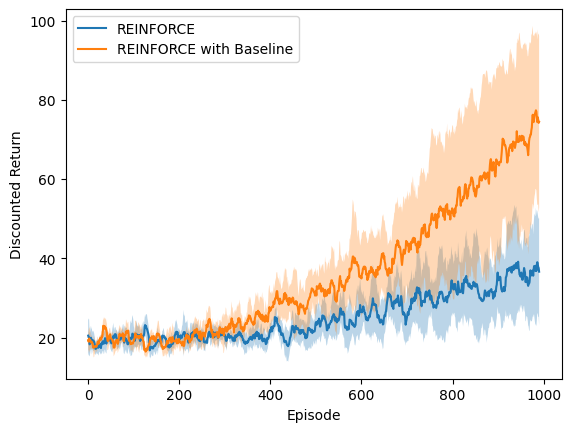

In [24]:
reinforce_returns = run_reinforce(
    lr= 1e-4,
    T_initial= 10,
    T_decay = 0.99,
    T_min = 0.5,
    isDecay = True,
    num_episodes = 1000,
    num_runs = 5,
    device = "cuda"
)

reinforce_with_baseline_returns = run_reinforce_with_baseline(
    lr_pi= 1e-4,
    lr_v = 1e-3,
    T_initial= 10,
    T_decay = 0.99,
    T_min = 0.5,
    isDecay = True,
    num_episodes = 1000,
    num_runs = 5,
    device = "cuda"
)

plot_compare_smoothed_rewards(
    train_rewards_list=[reinforce_returns, reinforce_with_baseline_returns],
    labels=["REINFORCE", "REINFORCE with Baseline"],
    xlabel="Episode", ylabel="Discounted Return"
)

**Answer**
After 1000 episodes, the REINFORCE with Baseline algorithm achieves almost double the average discounted return compared to the base REINFORCE algorithm. In theory, subtracting a baseline $\hat v(S_t, w)$ from the returns $G_t$ reduces the variance of the estimator of the policy gradient and this should make each update to the policy's parameters more effective, which explains the faster learning despite the wider spread across runs.

### Q4b: Decay vs. Fixed Temperatures

Using device: cuda
Running REINFORCE with learning rate: 0.0001, initial temperature: 0.1, isDecay: False
Using device: cuda
Running REINFORCE with learning rate: 0.0001, initial temperature: 1.0, isDecay: False
Using device: cuda
Running REINFORCE with learning rate: 0.0001, initial temperature: 10.0, isDecay: False


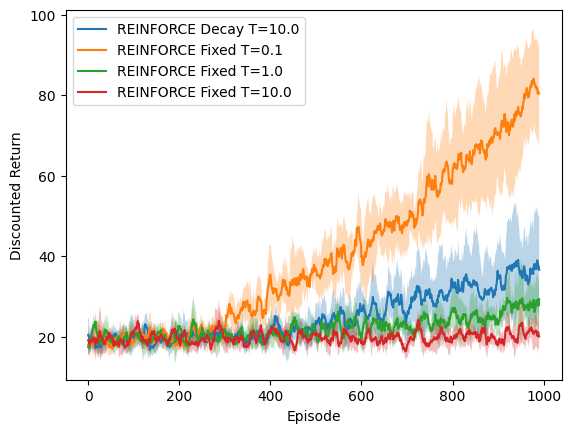

In [25]:
labels = ["REINFORCE Decay T=10.0", "REINFORCE Fixed T=0.1", "REINFORCE Fixed T=1.0", "REINFORCE Fixed T=10.0"]
train_returns_list = [reinforce_returns]

for T in [0.1, 1.0, 10.0]:
    returns = run_reinforce(
        lr= 1e-4,
        T_initial= T,
        isDecay = False,
        num_episodes = 1000,
        num_runs = 5,
        device = "cuda"
    )
    train_returns_list.append(returns)

plot_compare_smoothed_rewards(
    train_rewards_list=train_returns_list,
    labels=labels,
    xlabel="Episode", ylabel="Discounted Return"
)

**Answer**
For a fixed set of preferences, decreasing the temperature leads to less exploration (more greedy) policies by making the action probability distribution more peaky.

Fixed T=10 in red never improves its performance because it is always exploring. Fixed T=1.0 in green is still somewhat exploratory, which degrades its performance.

Surprisingly, the fixed T=0.1 curve in orange performs better than the annealing variant with initial T=10 in blue. One reason might be that the annealing variant's temperature never goes below 0.5, so it never converges close to a greedy policy even after it has learned a good policy network.

In contrast, although fixed T=0.1 is nearly greedy, it has enough exploration to find a good policy and then exploit that policy more effectively than all the other agents, which continue to take a larger proportion of suboptimal actions.

### Q4c: One-step Actor-Critic

In [26]:
def run_one_step_actor_critic(
    lr_pi=1e-4,
    lr_v=1e-3,
    T_initial=10,
    T_decay=0.99,
    T_min=0.5,
    isDecay=True,
    num_episodes=1000,
    num_runs=5,
    device="cpu"
):
    if device not in ["cpu", "cuda", "mps"]:
        raise ValueError(f"Invalid device '{device}'. Supported devices are 'cpu', 'cuda', and 'mps'.")
    elif device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
        print("cuda not available, falling back to cpu.")
    else:
        print(f"Using device: {device}")

    print(f"Running one-step Actor-Critic. REINFORCE Boltzmann Policy network LR: {lr_pi}, Value function LR: {lr_v}. Initial temperature: {T_initial}, isDecay: {isDecay}")

    all_returns = [] # Store return results for each run

    for run in range(num_runs):
        # Ensure different seed for each run
        env.reset(seed = RANDOM_SEED + run)

        # Initialize differentiable policy parameterization
        policy = BoltzmanPolicy(input_dim = 4, output_dim = 2, initial_temperature = T_initial).to(device)
        value = MLP(input_dim = 4, output_dim = 1).to(device)

        # Initialize Adam optimizer for policy parameters with default hyperparameters
        policy_optimizer = torch.optim.Adam(policy.parameters(), lr=lr_pi)
        value_optimizer = torch.optim.Adam(value.parameters(), lr=lr_v)

        # Track discounted return for each episode
        run_returns = []

        # Run training loop for specified number of episodes
        for episode in range(num_episodes):
            state, info = env.reset()

            episode_return = 0.0
            episode_steps = 0
            done = False
            truncated = False

            I = 1.0  # Initialize the discount factor for the policy gradient update

            while not (done or truncated):
                # Sample an action from the policy given the current state
                with torch.no_grad():
                    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)  # [1, 4]
                    action_probs = policy(state_tensor).squeeze(0) # [2]
                    action = torch.multinomial(action_probs, num_samples=1).item()
                
                # Take the action in the environment
                next_state, reward, done, truncated, info = env.step(action)
                next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device) # [1, 4]

                # Compute the value of the current state and the next state
                current_value = value(state_tensor).squeeze()
                next_value = value(next_state_tensor).squeeze().detach() if not done else 0

                # Compute advantage
                delta = reward + GAMMA * next_value - current_value.detach()

                # Update critic
                value_loss = (reward + GAMMA * next_value - current_value).pow(2)
                value_optimizer.zero_grad()
                value_loss.backward()
                value_optimizer.step()
                
                # Update actor
                pi = policy(state_tensor).squeeze() # [2]
                J = I * delta * torch.log(pi[action] + 1e-8)
                loss_policy = -J
                
                policy_optimizer.zero_grad()
                loss_policy.backward()
                policy_optimizer.step()

                # Update episode return and step count
                episode_return += (GAMMA ** episode_steps) * reward
                episode_steps += 1
                I = GAMMA * I
                state = next_state

            # Decay temperature after each episode
            if isDecay:
                policy.decay_temperature(decay_rate=T_decay, T_min=T_min)

            run_returns.append(episode_return)

        all_returns.append(run_returns)

    return all_returns

Using device: cuda
Running REINFORCE with learning rate: 0.0001, initial temperature: 10, isDecay: True
Using device: cuda
Running one-step Actor-Critic. REINFORCE Boltzmann Policy network LR: 0.0001, Value function LR: 0.001. Initial temperature: 10, isDecay: True


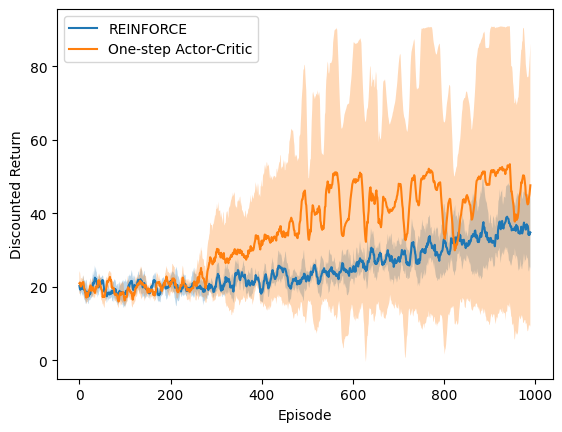

In [27]:
reinforce_returns = run_reinforce(
    lr= 1e-4,
    T_initial= 10,
    T_decay = 0.99,
    T_min = 0.5,
    isDecay = True,
    num_episodes = 1000,
    num_runs = 5,
    device = "cuda"
)

actor_critic_returns = run_one_step_actor_critic(
    lr_pi= 1e-4,
    lr_v = 1e-3,
    T_initial= 10,
    T_decay = 0.99,
    T_min = 0.5,
    isDecay = True,
    num_episodes = 1000,
    num_runs = 5,
    device = "cuda"
)

plot_compare_smoothed_rewards(
    train_rewards_list=[reinforce_returns, actor_critic_returns],
    labels=["REINFORCE", "One-step Actor-Critic"],
    xlabel="Episode", ylabel="Discounted Return"
)

**Observations**:

The one-step Actor-Critic algorithm learns faster and performs slightly better than REINFORCE on average, but it exhibits higher variance across seeds. This is likely because the actor-critic algorithm updates the policy at every step based on the critic's value estimates, making it more sensitive to the accuracy and speed of convergence of the critic's estimates. 

### Q4d: Actor-Critic with Different Critic Learning Rates

Using device: cuda
Running one-step Actor-Critic. REINFORCE Boltzmann Policy network LR: 0.0001, Value function LR: 0.0001. Initial temperature: 10, isDecay: True
Using device: cuda
Running one-step Actor-Critic. REINFORCE Boltzmann Policy network LR: 0.0001, Value function LR: 0.0005. Initial temperature: 10, isDecay: True
Using device: cuda
Running one-step Actor-Critic. REINFORCE Boltzmann Policy network LR: 0.0001, Value function LR: 0.002. Initial temperature: 10, isDecay: True


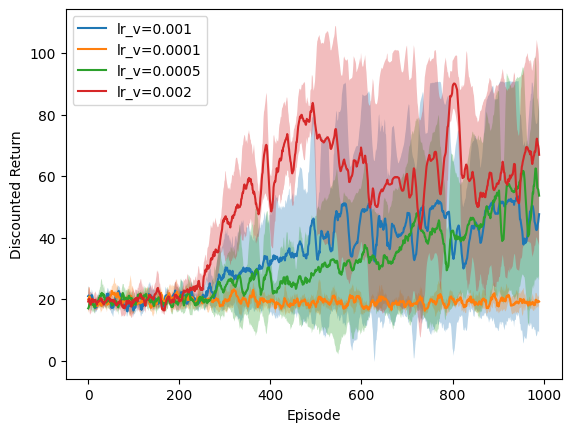

In [28]:
lr_returns = []
for lr in [1e-4, 5e-4, 2e-3]:
    returns = run_one_step_actor_critic(
                                lr_pi= 1e-4,
                                lr_v = lr,
                                T_initial= 10,
                                T_decay = 0.99,
                                T_min = 0.5,
                                isDecay = True,
                                num_episodes = 1000,
                                num_runs = 5,
                                device = "cuda"
                            )
    lr_returns.append(returns)

    
plot_compare_smoothed_rewards(
    train_rewards_list=[actor_critic_returns] + lr_returns,
    labels=[f"lr_v={lr}" for lr in [1e-3, 1e-4, 5e-4, 2e-3]],
    xlabel="Episode", ylabel="Discounted Return"
)

Lowering the critic learning rate until it matches the actor's ($\alpha_V = 0.0001$) worsens performance.

This is because the actor's policy gradient is proportional to the one-step TD error, which serves as an estimate of the advantage and depends entirely on the critic's value function.

If the critic learns slower or at the same speed as the actor, then a slow critic would produce less accurate advantages, but the fast actor would still make large updates based on them. This could cause instability and even seems to prevent convergence in the case where $\alpha_V = \alpha_\pi = 0.0001$. 

Conversely, setting $\alpha_V$ too high (i.e. 0.002) can also hurt, as the critic may overshoot and produce unstable value estimates, again degrading the signal the actor relies on.

The best performance is achieved when the critic learns fast enough to provide accurate advantages without becoming unstable, which in our case corresponds to $\alpha_V = 0.001$ in blue and $0.0005$ in green.